In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import os

# --- 1. Load the processed measles data ---
processed_data_path = '../data/processed/measles_cases_processed_timeseries.csv'
df_cases = pd.read_csv(processed_data_path, index_col='Year', parse_dates=True)

# --- 2. Convert from 'wide' back to 'long' format ---
# ML models prefer each row to be a single observation (Country-Year).
df_long = df_cases.melt(ignore_index=False, var_name='CountryCode', value_name='Cases').reset_index()
print("--- Reshaped to Long Format ---")
print(df_long.head())

# --- 3. Create the Target Variable ---
# Our goal is to predict next year's cases.
# We create a new column 'Cases_Next_Year' by shifting the 'Cases' column up by one step for each country.
df_long.sort_values(by=['CountryCode', 'Year'], inplace=True)
df_long['Cases_Next_Year'] = df_long.groupby('CountryCode')['Cases'].shift(-1)


# --- 4. Create Lagged Features (Time-based Features) ---
# The model needs past data as input. Let's give it the case count from 1 year ago.
df_long['Cases_Lag_1'] = df_long.groupby('CountryCode')['Cases'].shift(1)


# --- 5. Create Time-based Features ---
df_long['Year_Num'] = df_long['Year'].dt.year


# --- 6. Clean up the data ---
# Drop rows with NaN values (the first year for the lag, and the last year for the target)
df_final = df_long.dropna(subset=['Cases_Next_Year', 'Cases_Lag_1'])

print("\n--- Final DataFrame with Features and Target ---")
print(df_final.head())

--- Reshaped to Long Format ---
        Year CountryCode  Cases
0 1974-01-01         ABW    0.0
1 1975-01-01         ABW    0.0
2 1976-01-01         ABW    0.0
3 1977-01-01         ABW    0.0
4 1978-01-01         ABW    0.0

--- Final DataFrame with Features and Target ---
        Year CountryCode  Cases  Cases_Next_Year  Cases_Lag_1  Year_Num
1 1975-01-01         ABW    0.0              0.0          0.0      1975
2 1976-01-01         ABW    0.0              0.0          0.0      1976
3 1977-01-01         ABW    0.0              0.0          0.0      1977
4 1978-01-01         ABW    0.0              0.0          0.0      1978
5 1979-01-01         ABW    0.0              0.0          0.0      1979


In [2]:
# --- Define Features (X) and Target (y) ---
# We are excluding 'CountryCode' and 'Year' for now to keep the model simple.
# They are not numerical features that XGBoost can use directly without encoding.
features = ['Cases', 'Cases_Lag_1', 'Year_Num']
target = 'Cases_Next_Year'

X = df_final[features]
y = df_final[target]

# --- Split data into Training and Testing sets (Time-based) ---
split_year = 2015
train_filter = df_final['Year_Num'] < split_year
test_filter = df_final['Year_Num'] >= split_year

X_train, X_test = X[train_filter], X[test_filter]
y_train, y_test = y[train_filter], y[test_filter]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# --- Initialize and Train the XGBoost Model ---
# n_estimators: number of boosting rounds (trees)
# learning_rate: step size shrinkage to prevent overfitting
# objective: defines the loss function, 'reg:squarederror' is for regression tasks
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    early_stopping_rounds=10 # Stop training if performance doesn't improve
)

print("\n--- Training XGBoost Model ---")
# The eval_set allows the model to monitor its performance on the test set
# during training, which is used for early stopping.
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False # Set to True if you want to see training progress
)
print("--- Model training complete ---")

Training data shape: (9000, 3)
Testing data shape: (2025, 3)

--- Training XGBoost Model ---
--- Model training complete ---



Model Mean Absolute Error (MAE) on the test set: 205.55
This means, on average, the model's prediction for next year's cases was off by ~206 cases.


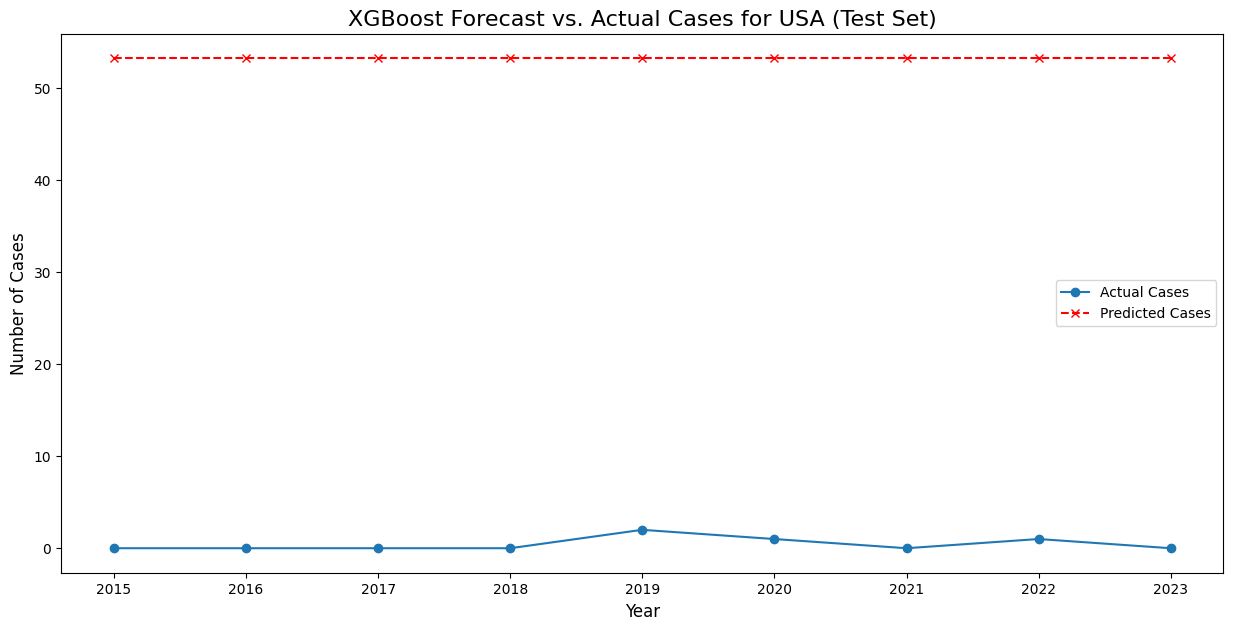

In [3]:
# --- Make Predictions on the Test Set ---
y_pred = model.predict(X_test)


# --- Evaluate the Model ---
mae = mean_absolute_error(y_test, y_pred)
print(f"\nModel Mean Absolute Error (MAE) on the test set: {mae:.2f}")
print(f"This means, on average, the model's prediction for next year's cases was off by ~{int(round(mae,0))} cases.")


# --- Visualize Predictions for a Single Country ---
# To make sense of the results, let's plot predictions vs actuals for one country.
country_code = 'USA'

# Create a DataFrame with test results for easy plotting
results_df = df_final[test_filter].copy()
results_df['Prediction'] = y_pred

# Filter for the specific country
country_results = results_df[results_df['CountryCode'] == country_code]

plt.figure(figsize=(15, 7))
plt.plot(country_results['Year'], country_results['Cases_Next_Year'], marker='o', label='Actual Cases')
plt.plot(country_results['Year'], country_results['Prediction'], marker='x', linestyle='--', color='red', label='Predicted Cases')
plt.title(f'XGBoost Forecast vs. Actual Cases for {country_code} (Test Set)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.legend()
plt.show()